# Treinamento da BearingCNN no Dataset Paderborn (PU Dataset)

**Projeto:** Diagnóstico de Falhas em Rolamentos Industriais via CWT + CNN  
**Dataset:** Paderborn University (PU Dataset — 64 kHz, Falhas Reais por Fadiga)  
**Classes:** 3 Classes (`normal`, `inner_race`, `outer_race`)  
**Objetivo:** Treinar do zero a arquitetura convolucional própria `BearingCNN` (com *Global Average Pooling*) sobre escalogramas CWT gerados a partir dos sinais de alta resolução de Paderborn.

---

## 1. Importação de Módulos e Configurações

In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name in ['1_cwru', '2_paderborn', '3_cross_domain', '4_order_tracking'] else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Fixar seeds para 100% de reprodutibilidade
from src.config import RANDOM_SEED, PADERBORN_PROCESSED_DIR, NUM_EPOCHS, LEARNING_RATE
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

from src.cnn_processor import train_and_evaluate_bearing_cnn, get_data_loaders
from src.visualization import plot_training_curves, plot_confusion_matrix

## 2. Treinamento da BearingCNN (Própria) com Checkpointing Automático

In [2]:
# Treinamento da rede própria sobre o dataset Paderborn processado
res_cnn = train_and_evaluate_bearing_cnn(
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    data_dir=PADERBORN_PROCESSED_DIR,
    checkpoint_name="checkpoint_paderborn_bearing_cnn_best.pth"
)

[INFO] EXPERIMENTO BEARING CNN (PRÓPRIA) | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.5552 - Acc: 89.92% | Val Loss: 0.1380 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0822 - Acc: 99.90% | Val Loss: 0.0266 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0277 - Acc: 99.94% | Val Loss: 0.0091 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0142 - Acc: 99.94% | Val Loss: 0.0049 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0075 - Acc: 99.98% | Val Loss: 0.0031 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0053 - Acc: 100.00% | Val Loss: 0.0020 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 06/10.
Época [07/10] | Treino Loss: 0.0051 - Acc: 99.98% | Val Loss: 0.0016 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/1

## 3. Avaliação e Gráficos de Desempenho

[INFO] Figura salva em: ../../docs/images/training_curves_paderborn_bearing_cnn.png


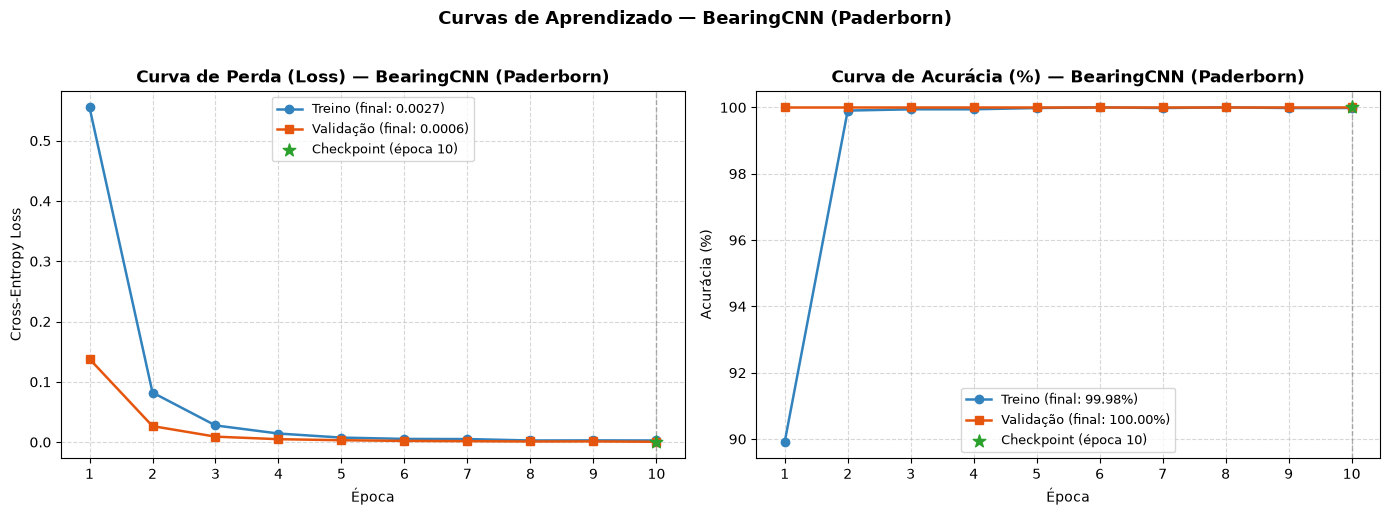

 RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (PADERBORN — BEARING CNN) 
              precision    recall  f1-score   support

  inner_race     1.0000    0.9973    0.9987       372
      normal     1.0000    1.0000    1.0000       372
  outer_race     0.9973    1.0000    0.9987       372

    accuracy                         0.9991      1116
   macro avg     0.9991    0.9991    0.9991      1116
weighted avg     0.9991    0.9991    0.9991      1116

[INFO] Figura salva em: ../../docs/images/confusion_matrix_paderborn_bearing_cnn.png


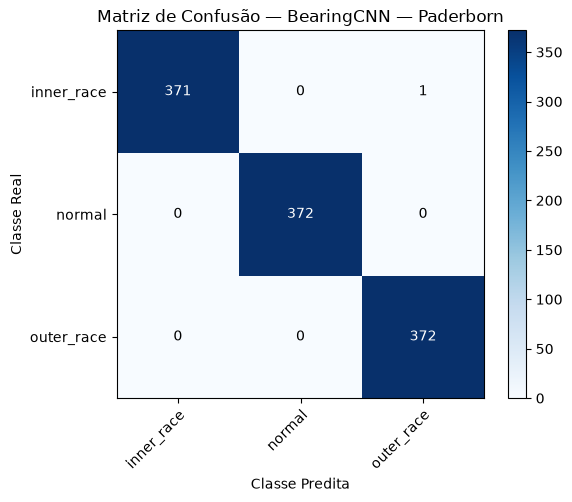

In [3]:
# 1. Curvas de Aprendizado (Loss e Acurácia)
plot_training_curves(
    res_cnn['history'],
    model_name="BearingCNN (Paderborn)",
    save_path="../../docs/images/training_curves_paderborn_bearing_cnn.png"
)

# 2. Relatório de Classificação no Teste
print("=" * 80)
print(" RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (PADERBORN — BEARING CNN) ")
print("=" * 80)
print(classification_report(
    res_cnn['test_labels'],
    res_cnn['test_preds'],
    target_names=res_cnn['classes'],
    digits=4
))

# 3. Matriz de Confusão no Teste Inédito
plot_confusion_matrix(
    res_cnn,
    model_name="BearingCNN — Paderborn",
    save_path="../../docs/images/confusion_matrix_paderborn_bearing_cnn.png"
)